In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import os 
import time 
from tensorflow.keras import layers, models, optimizers, callbacks # callbacks আমদানি করা হলো
from tensorflow.keras.applications import ResNet50 
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

2025-12-13 19:47:08.383074: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765655228.568670      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765655228.623496      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
BASE_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [4]:
NUM_CLASSES = 38
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32

INITIAL_EPOCHS = 10  
FINE_TUNE_EPOCHS = 6 
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS 

MODEL_ID = "ResNet50" 
TRAIN_PORTION = 0.5

In [5]:
print("\nLoading Training Set...")
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path, labels="inferred", label_mode="int", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, color_mode="rgb", shuffle=True
)
total_batches = training_set.cardinality().numpy()

training_set = training_set.shuffle(buffer_size=100).take(int(total_batches * TRAIN_PORTION))
print(f"Training set loaded, using {int(total_batches * TRAIN_PORTION)} batches ({TRAIN_PORTION*100}%).")

validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, labels="inferred", label_mode="int", image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, color_mode="rgb", shuffle=True
)
test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, labels="inferred", label_mode="int", color_mode="rgb",
    batch_size=1, image_size=IMG_SIZE, shuffle=False, 
)
class_name = test_set.class_names


Loading Training Set...
Found 70295 files belonging to 38 classes.


I0000 00:00:1765655273.670810      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765655273.671526      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training set loaded, using 1098 batches (50.0%).
Found 17572 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [6]:
base_resnet50 = ResNet50(
    weights="imagenet", include_top=False, input_shape=IMG_SIZE + (3,)
)
base_resnet50.trainable = False

resnet_model = tf.keras.models.Sequential([ 
    base_resnet50,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax") 
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
resnet_model.compile(
    optimizer=optimizers.Adam(1e-3), 
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n--- ResNet50 Model Summary (Feature Extraction) ---")
# 
resnet_model.summary()


--- ResNet50 Model Summary (Feature Extraction) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,122,022 (92.02 MB)

 Trainable params: 534,310 (2.04 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
print(f"\nStarting Phase 1 (Feature Extraction) for {INITIAL_EPOCHS} epochs...")
start_time = time.time() 
history_initial = resnet_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=INITIAL_EPOCHS
)
print("Phase 1 finished.")


Starting Phase 1 (Feature Extraction) for 10 epochs...
Epoch 1/10


I0000 00:00:1765655297.511192     119 service.cc:148] XLA service 0x7a1f8c0035d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765655297.511985     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765655297.512005     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765655300.053394     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/1098 ━━━━━━━━━━━━━━━━━━━━ 1:26 79ms/step - accuracy: 0.0078 - loss: 4.2229      

I0000 00:00:1765655305.069806     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1098/1098 ━━━━━━━━━━━━━━━━━━━━ 164s 131ms/step - accuracy: 0.7699 - loss: 0.8080 - val_accuracy: 0.9426 - val_loss: 0.1687
Epoch 2/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 152s 137ms/step - accuracy: 0.9357 - loss: 0.1984 - val_accuracy: 0.9479 - val_loss: 0.1520
Epoch 3/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 152s 137ms/step - accuracy: 0.9451 - loss: 0.1586 - val_accuracy: 0.9567 - val_loss: 0.1219
Epoch 4/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 152s 137ms/step - accuracy: 0.9550 - loss: 0.1286 - val_accuracy: 0.9434 - val_loss: 0.1662
Epoch 5/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 152s 137ms/step - accuracy: 0.9584 - loss: 0.1274 - val_accuracy: 0.9607 - val_loss: 0.1183
Epoch 6/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 153s 137ms/step - accuracy: 0.9634 - loss: 0.1026 - val_accuracy: 0.9559 - val_loss: 0.1308
Epoch 7/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 153s 138ms/step - accuracy: 0.9648 - loss: 0.1033 - val_accuracy: 0.9618 - val_loss: 0.1177
Epoch 8/10
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 152s 137ms/step - accuracy: 0.9

In [9]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1
)

ft_callbacks = [early_stopping, lr_scheduler]

In [10]:
base_resnet50.trainable = True
UNFREEZE_LAYERS_FROM = len(base_resnet50.layers) - 40 
for layer in base_resnet50.layers[:UNFREEZE_LAYERS_FROM]:
    layer.trainable = False 

resnet_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"\nStarting Phase 2 (Fine-Tuning) for max {FINE_TUNE_EPOCHS} epochs with callbacks and LR 1e-5...")


Starting Phase 2 (Fine-Tuning) for max 6 epochs with callbacks and LR 1e-5...


In [11]:
history_fine_tune = resnet_model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_initial.epoch[-1] + 1,
    callbacks=ft_callbacks 
)

end_time = time.time() 
training_time = end_time - start_time
print(f"Training finished. Total time: {training_time:.2f} seconds.")

Epoch 11/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 240s 197ms/step - accuracy: 0.9061 - loss: 0.3836 - val_accuracy: 0.9740 - val_loss: 0.0839 - learning_rate: 1.0000e-05
Epoch 12/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 211s 191ms/step - accuracy: 0.9798 - loss: 0.0604 - val_accuracy: 0.9797 - val_loss: 0.0668 - learning_rate: 1.0000e-05
Epoch 13/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 211s 191ms/step - accuracy: 0.9882 - loss: 0.0339 - val_accuracy: 0.9820 - val_loss: 0.0592 - learning_rate: 1.0000e-05
Epoch 14/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 211s 190ms/step - accuracy: 0.9927 - loss: 0.0214 - val_accuracy: 0.9854 - val_loss: 0.0517 - learning_rate: 1.0000e-05
Epoch 15/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 211s 191ms/step - accuracy: 0.9954 - loss: 0.0137 - val_accuracy: 0.9853 - val_loss: 0.0526 - learning_rate: 1.0000e-05
Epoch 16/16
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 211s 190ms/step - accuracy: 0.9965 - loss: 0.0119 - val_accuracy: 0.9854 - val_loss: 0.0491 - learning_rate: 1.0000e-05
Restoring model weight

In [12]:
train_loss, train_acc = resnet_model.evaluate(training_set, verbose=0)
print(f'\nTraining accuracy: {train_acc:.4f}')

val_loss, val_acc = resnet_model.evaluate(validation_set, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')


Training accuracy: 0.9998
Validation accuracy: 0.9854


In [13]:
y_pred_probs = resnet_model.predict(test_set, verbose=0) 
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = true_categories.numpy()
predicted_categories = tf.argmax(y_pred_probs, axis=1).numpy()

report = classification_report(Y_true, predicted_categories, target_names=class_name, output_dict=True)

print("\n--- Classification Report ---")
print(classification_report(Y_true, predicted_categories, target_names=class_name, digits=4))


--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9843    0.9921    0.9881       504
                                 Apple___Black_rot     0.9940    0.9980    0.9960       497
                          Apple___Cedar_apple_rust     0.9909    0.9932    0.9921       440
                                   Apple___healthy     0.9940    0.9841    0.9890       502
                               Blueberry___healthy     0.9934    0.9978    0.9956       454
          Cherry_(including_sour)___Powdery_mildew     0.9976    0.9929    0.9952       421
                 Cherry_(including_sour)___healthy     1.0000    0.9978    0.9989       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9329    0.9488    0.9407       410
                       Corn_(maize)___Common_rust_     1.0000    0.9979    0.9990       477
               Corn_(maize)___Northern_Leaf_Blig

In [14]:
history = {
    'accuracy': history_initial.history['accuracy'] + history_fine_tune.history['accuracy'],
    'val_accuracy': history_initial.history['val_accuracy'] + history_fine_tune.history['val_accuracy'],
    'loss': history_initial.history['loss'] + history_fine_tune.history['loss'],
    'val_loss': history_initial.history['val_loss'] + history_fine_tune.history['val_loss'],
}

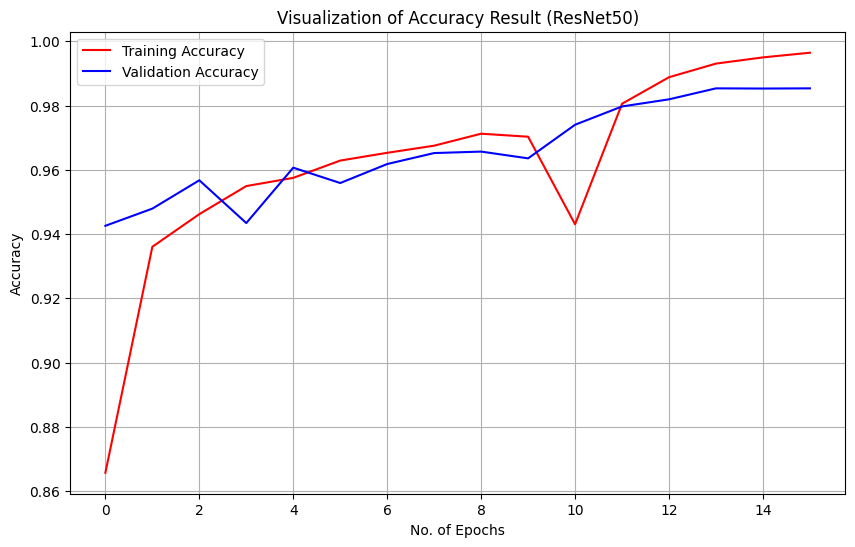

In [15]:
epochs_range = range(len(history['accuracy']))
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title(f'Visualization of Accuracy Result ({MODEL_ID})')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
metrics_summary = {
    'Model': MODEL_ID, 
    'Accuracy': report['accuracy'],
    'Precision (Wgt Avg)': report['weighted avg']['precision'], 
    'Recall (Wgt Avg)': report['weighted avg']['recall'],
    'F1-Score (Wgt Avg)': report['weighted avg']['f1-score'],
    'Training Time (s)': training_time, 
}

In [17]:
df_metrics = pd.DataFrame([metrics_summary])
results_file = 'model_performance_summary.csv'

if not os.path.exists(results_file):
    df_metrics.to_csv(results_file, index=False)
else:
    df_metrics.to_csv(results_file, mode='a', header=False, index=False)
    
print(f"\n✅ Metrics successfully saved/appended to {results_file}")


✅ Metrics successfully saved/appended to model_performance_summary.csv
